In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
out_fpath="/g100_work/optim_IAC/research/noc/otooth/OptimESM_IHO/World_Seas_IHO_v3/World_Seas_IHO_v3_polygons.parquet"
df_poly = pd.read_parquet(out_fpath)

df_poly

,ID,Name,MRGID,Longitudes,Latitudes
0,0,Rio de La Plata,4325,"[[-54.943023652717045, -54.978746687192626, -5...","[[-34.947906883078645, -34.97439280639835, -35..."
1,1,Bass Strait,4366,"[[149.90464234356938, 149.9049998519617, 149.9...","[[-37.54324781853184, -37.54805552943908, -37...."
2,2,Great Australian Bight,4276,"[[143.53250818354263, 143.54855731580784, 143....","[[-38.855345058560204, -38.89580867390668, -38..."
3,3,Tasman Sea,4365,"[[159.03333000000018, 159.03983414634163, 159....","[[-29.999999999999986, -30.043495934959335, -3..."
4,4,Mozambique Channel,4261,"[[43.38217926066437, 43.426910578414024, 43.47...","[[-11.370205640977488, -11.374667237992885, -1..."
...,...,...,...,...,...
96,96,Laccadive Sea,4269,"[[79.19056582495296, 79.20560240772511, 79.205...","[[9.28162992038466, 9.280296445224849, 9.28018..."
97,97,Skagerrak,2379,"[[10.66160702664314, 10.662945270907699, 10.66...","[[59.91287636715083, 59.910394549469004, 59.90..."
98,98,Norwegian Sea,2353,"[[16.72106314339885, 16.78890655530549, 16.856...","[[76.5645473926769, 76.50603497544391, 76.4475..."
99,99,Ligurian Sea,3363,"[[9.834412487214706, 9.835301503777828, 9.8349...","[[44.0485148685363, 44.04729517147973, 44.0472..."


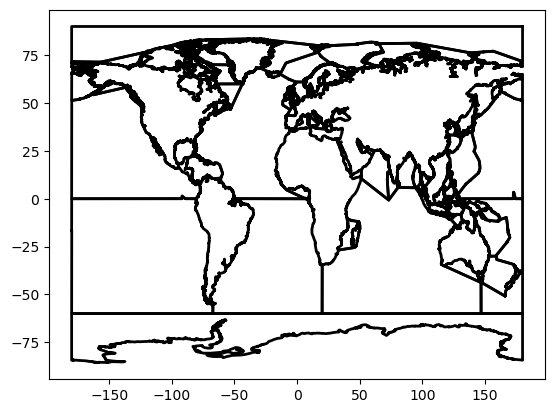

In [13]:
for row in df_poly.iterrows():
    if len(row[1]['Longitudes']) == 1:
        plt.plot(row[1]['Longitudes'][0], row[1]['Latitudes'][0], lw=2, color='k')
    elif len(row[1]['Longitudes']) > 1:
        for n in range(len(row[1]['Longitudes'])):
            plt.plot(row[1]['Longitudes'][n], row[1]['Latitudes'][n], lw=2, color='k')
    else:
        raise ValueError("No polygon coordinates to plot.")

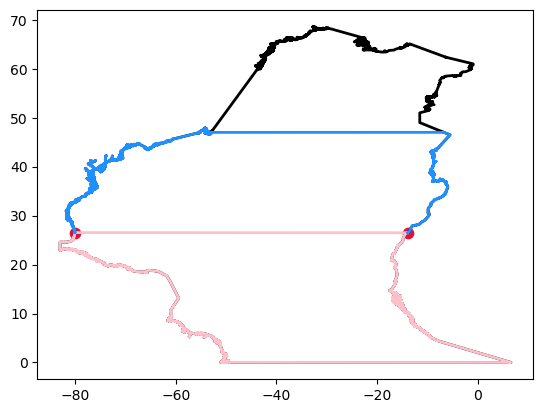

In [14]:
plt.figure()
df_plot = df_poly[df_poly['Name'] == 'North Atlantic Ocean']
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0], lw=2, color='k')

plt.scatter(df_plot['Longitudes'].item()[0][142042], df_plot['Latitudes'].item()[0][142042], s=55, color='crimson')
plt.scatter(df_plot['Longitudes'].item()[0][273614], df_plot['Latitudes'].item()[0][273614], s=55, color='crimson')

plt.plot(df_plot['Longitudes'].item()[0][142042:273615], df_plot['Latitudes'].item()[0][142042:273615], lw=2, color='pink')
plt.plot(df_plot['Longitudes'].item()[0][[273615, 142042]], df_plot['Latitudes'].item()[0][[273615, 142042]], lw=2, color='pink')

plt.plot(df_plot['Longitudes'].item()[0][273615:331222], df_plot['Latitudes'].item()[0][273615:331222], lw=2, color='dodgerblue')
plt.plot(df_plot['Longitudes'].item()[0][81267:142043], df_plot['Latitudes'].item()[0][81267:142043], lw=2, color='dodgerblue')
plt.plot(df_plot['Longitudes'].item()[0][[331222, 81267]], df_plot['Latitudes'].item()[0][[331222, 81267]], lw=2, color='dodgerblue')

[-13.93871081 -13.93932843 -13.93985963 ... -80.05152261 -80.04627073
 -13.93871081]
[26.49988914 26.4995774  26.49932015 ... 26.50281227 26.53237045
 26.49988914]


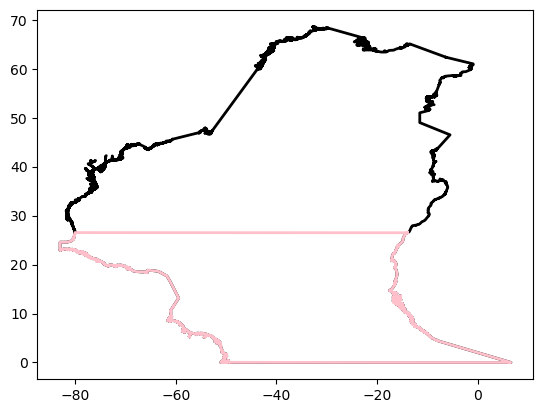

In [15]:
# Define Tropical NA:
lon_TNA = np.concatenate([df_plot['Longitudes'].item()[0][142042:273615], df_plot['Longitudes'].item()[0][[273615, 142042]]])
lat_TNA = np.concatenate([df_plot['Latitudes'].item()[0][142042:273615], df_plot['Latitudes'].item()[0][[273615, 142042]]])

print(lon_TNA)
print(lat_TNA)

plt.figure()
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0], lw=2, color='k')
plt.plot(lon_TNA, lat_TNA, lw=2, color='pink')

[ -6.71336194  -6.63135976  -6.54935759 ... -52.90754163 -52.91079593
  -6.71336194]
[47.01154366 46.97747847 46.94341328 ... 46.99868405 47.00052381
 47.01154366]


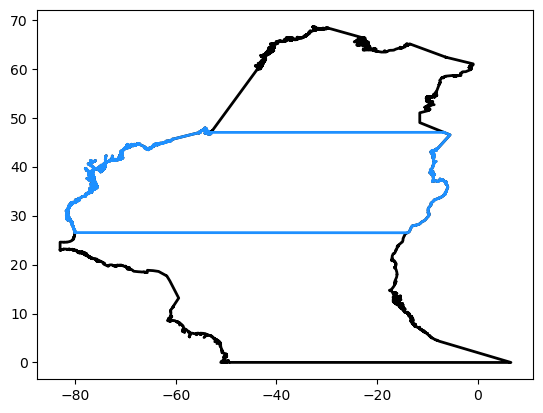

In [16]:
# Define STNA:
lon_STNA = np.concatenate([df_plot['Longitudes'].item()[0][81267:142043],
                           df_plot['Longitudes'].item()[0][[142042, 273615]],
                           df_plot['Longitudes'].item()[0][273615:331222],
                           df_plot['Longitudes'].item()[0][[331222, 81267]]
                           ])


lat_STNA = np.concatenate([df_plot['Latitudes'].item()[0][81267:142043],
                           df_plot['Latitudes'].item()[0][[142042, 273615]],
                           df_plot['Latitudes'].item()[0][273615:331222],
                           df_plot['Latitudes'].item()[0][[331222, 81267]]
                           ])

print(lon_STNA)
print(lat_STNA)

plt.figure()
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0], lw=2, color='k')
plt.plot(lon_STNA, lat_STNA, lw=2, color='dodgerblue')

[-6.26384282 -6.17706036 -6.09027789 ... -6.43020632 -6.34702457
 -6.26384282]


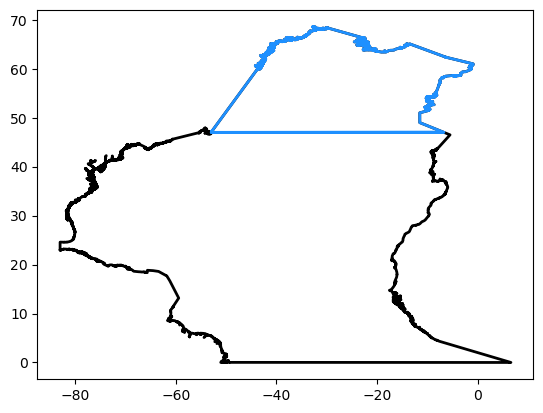

In [17]:
# Define eSPNA:
lon_eSPNA = np.concatenate([df_plot['Longitudes'].item()[0][:81267],
                            df_plot['Longitudes'].item()[0][[331222, 81267]],
                            df_plot['Longitudes'].item()[0][331222:],
                           ])


lat_eSPNA = np.concatenate([df_plot['Latitudes'].item()[0][:81267],
                            df_plot['Latitudes'].item()[0][[331222, 81267]],
                            df_plot['Latitudes'].item()[0][331222:],
                           ])

print(lon_eSPNA)

plt.figure()
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0], lw=2, color='k')
plt.plot(lon_eSPNA, lat_eSPNA, lw=2, color='dodgerblue')

In [18]:
df_plot['Latitudes'].item()[0][[331222, 81267]]

array([47.00052381, 47.01154366])

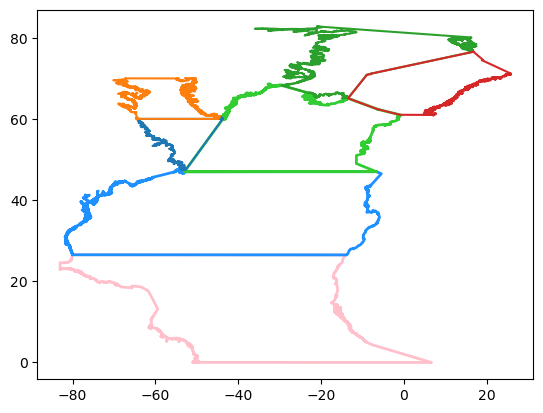

In [19]:
# Figure: North Atlantic IHO v3 - Tropical NA, Subtropical NA, & eastern Subpolar NA:
plt.figure()
plt.plot(lon_TNA, lat_TNA, lw=2, color='pink')
plt.plot(lon_STNA, lat_STNA, lw=2, color='dodgerblue')
plt.plot(lon_eSPNA, lat_eSPNA, lw=2, color='limegreen')

df_plot = df_poly[df_poly['Name'] == 'Labrador Sea']
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0])

df_plot = df_poly[df_poly['Name'] == 'Davis Strait']
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0])

df_plot = df_poly[df_poly['Name'] == 'Greenland Sea']
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0])

df_plot = df_poly[df_poly['Name'] == 'Norwegian Sea']
plt.plot(df_plot['Longitudes'].item()[0], df_plot['Latitudes'].item()[0])

In [11]:
df_poly['Name'].values

array(['Rio de La Plata', 'Bass Strait', 'Great Australian Bight',
       'Tasman Sea', 'Mozambique Channel', 'Savu Sea', 'Timor Sea',
       'Bali Sea', 'Coral Sea', 'Flores Sea', 'Solomon Sea',
       'Arafura Sea', 'Gulf of Boni', 'Java Sea', 'Ceram Sea',
       'Bismarck Sea', 'Banda Sea', 'Gulf of California', 'Bay of Fundy',
       'Strait of Gibraltar', 'Alboran Sea', 'Caribbean Sea',
       'Gulf of Alaska', 'Bering Sea', 'Chukchi Sea', 'Beaufort Sea',
       'Labrador Sea', 'Hudson Strait', 'Davis Strait', 'Baffin Bay',
       'Lincoln Sea', 'Bristol Channel',
       "Irish Sea and St. George's Channel",
       'Inner Seas off the West Coast of Scotland', 'Gulf of Aden',
       'Gulf of Oman', 'Red Sea', 'Gulf of Aqaba', 'Persian Gulf',
       'Ionian Sea', 'Tyrrhenian Sea', 'Adriatic Sea', 'Gulf of Suez',
       'Mediterranean Sea - Eastern Basin', 'Aegean Sea',
       'Sea of Marmara', 'Singapore Strait', 'Celebes Sea',
       'Malacca Strait', 'Sulu Sea', 'Gulf of Thailand'

In [10]:
df_NA_poly = df_poly[df_poly['Name'].isin(['Labrador Sea', 'Davis Strait', 'Greenland Sea', 'Norwegian Sea'])]

df_NA_poly

,ID,Name,MRGID,Longitudes,Latitudes
26,26,Labrador Sea,4291,"[[-44.06702363483279, -44.06667697406303, -44....","[[60.3309059144765, 60.32678604104309, 60.3248..."
28,28,Davis Strait,4250,"[[-47.44768404917946, -47.438509940881005, -47...","[[60.813046574639785, 60.811735272265096, 60.8..."
86,86,Greenland Sea,2356,"[[-20.861681103196304, -20.772145991165416, -2...","[[82.78065447115985, 82.77410410331477, 82.767..."
98,98,Norwegian Sea,2353,"[[16.72106314339885, 16.78890655530549, 16.856...","[[76.5645473926769, 76.50603497544391, 76.4475..."
